# Phase 3 — Neural Network Model
## EPL Match Result Prediction (MLP)
> ต้องรัน `01_eda_preprocessing.ipynb` ก่อน เพื่อให้มีไฟล์ `epl_splits.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
os.makedirs('../models', exist_ok=True)
os.makedirs('../app/static/images', exist_ok=True)
print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU available: False


In [2]:
# โหลด Splits จาก Phase 1
splits = joblib.load('../data/processed/epl_splits.pkl')
X_train = splits['X_train'].values
X_val   = splits['X_val'].values
X_test  = splits['X_test'].values
y_train = splits['y_train']
y_val   = splits['y_val']
y_test  = splits['y_test']
feature_cols = splits['feature_cols']
le = splits['label_encoder']

NUM_CLASSES = len(le.classes_)
N_FEATURES  = X_train.shape[1]

print(f'Train : {X_train.shape}')
print(f'Val   : {X_val.shape}')
print(f'Test  : {X_test.shape}')
print(f'Classes ({NUM_CLASSES}): {le.classes_}')
print(f'Features ({N_FEATURES}): {feature_cols}')

Train : (266, 19)
Val   : (57, 19)
Test  : (57, 19)
Classes (3): ['A' 'D' 'H']
Features (19): ['FTHG', 'FTAG', 'HS', 'AS', 'HST', 'AST', 'HC', 'AC', 'HF', 'AF', 'HY', 'AY', 'HR', 'AR', 'goal_diff', 'home_shot_acc', 'away_shot_acc', 'corner_diff', 'foul_diff']


In [3]:
# Feature Scaling
scaler_nn = StandardScaler()
X_train_sc = scaler_nn.fit_transform(X_train)
X_val_sc   = scaler_nn.transform(X_val)
X_test_sc  = scaler_nn.transform(X_test)

# One-Hot Encode Targets
y_train_ohe = keras.utils.to_categorical(y_train, num_classes=NUM_CLASSES)
y_val_ohe   = keras.utils.to_categorical(y_val,   num_classes=NUM_CLASSES)
y_test_ohe  = keras.utils.to_categorical(y_test,  num_classes=NUM_CLASSES)
print('Preprocessing complete ✓')

Preprocessing complete ✓


### 🏗️ MLP Architecture: Input → Dense → BatchNorm → Dropout → Output

In [4]:
def build_mlp(input_dim, num_classes, units=(256, 128, 64),
              dropout_rate=0.3, learning_rate=0.001):
    model = Sequential(name='EPL_MLP')

    # Layer 1
    model.add(Dense(units[0], activation='relu', input_shape=(input_dim,),
                    kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    # Layer 2
    model.add(Dense(units[1], activation='relu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))

    # Layer 3
    model.add(Dense(units[2], activation='relu', kernel_initializer='he_normal'))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate * 0.5))

    # Output
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_mlp(N_FEATURES, NUM_CLASSES)
model.summary()

Model: "EPL_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           5,120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,259 (188.51 KB)

 Trainable params: 47,363 (185.01 KB)

 Non-trainable params: 896 (3.50 KB)

In [5]:
# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=25,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        '../models/nn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-7,
        verbose=1
    )
]
print('Callbacks ready ✓')

Callbacks ready ✓


In [6]:
# Train
tf.random.set_seed(42)
history = model.fit(
    X_train_sc, y_train_ohe,
    validation_data=(X_val_sc, y_val_ohe),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)
print(f'\nBest Val Accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'Stopped at epoch: {len(history.history["accuracy"])}')

Epoch 1/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.4375 - loss: 1.6104
Epoch 1: val_accuracy improved from None to 0.47368, saving model to ../models/nn_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4812 - loss: 1.2241 - val_accuracy: 0.4737 - val_loss: 1.0056 - learning_rate: 0.0010
Epoch 2/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7188 - loss: 0.6301
Epoch 2: val_accuracy improved from 0.47368 to 0.63158, saving model to ../models/nn_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6165 - loss: 0.8691 - val_accuracy: 0.6316 - val_loss: 0.7057 - learning_rate: 0.0010
Epoch 3/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7500 - loss: 0.5414
Epoch 3: val_accuracy improved from 0.63158 to 0.71930, saving model to ../models/nn_model.keras
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7068 - loss: 0.6224 - val_accuracy: 0.7193 - val_loss: 0.5829 - learning_rate: 0.0010
Epoch 4/200
1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/st

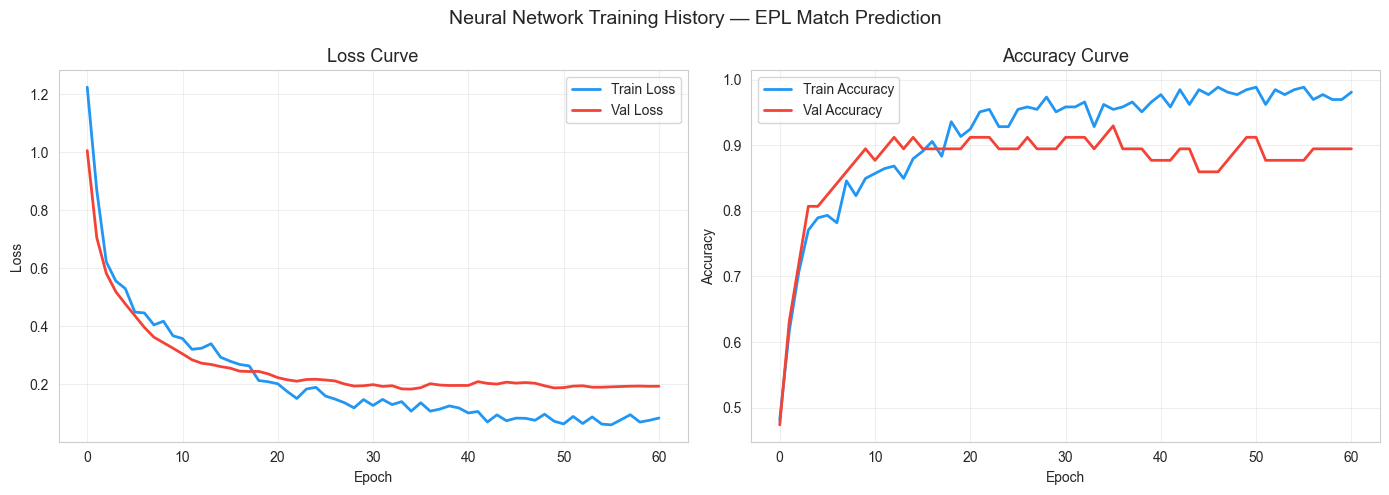

In [7]:
# Loss / Accuracy Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss', color='#2196F3', lw=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color='#F44336', lw=2)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color='#2196F3', lw=2)
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color='#F44336', lw=2)
axes[1].set_title('Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Neural Network Training History — EPL Match Prediction', fontsize=14)
plt.tight_layout()
plt.savefig('../app/static/images/nn_loss_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Load Best Model & Evaluate on Test Set
best_model = keras.models.load_model('../models/nn_model.keras')
y_pred_proba = best_model.predict(X_test_sc)
y_pred       = np.argmax(y_pred_proba, axis=1)

print('=== Neural Network — Test Set Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred, average="weighted"):.4f}')
print(f'F1-Score:  {f1_score(y_test, y_pred, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
=== Neural Network — Test Set Results ===
Accuracy:  0.8421
Precision: 0.8387
Recall:    0.8421
F1-Score:  0.8393

              precision    recall  f1-score   support

           A       0.88      0.96      0.92        23
           D       0.67      0.62      0.64        13
           H       0.90      0.86      0.88        21

    accuracy                           0.84        57
   macro avg       0.82      0.81      0.81        57
weighted avg       0.84      0.84      0.84        57



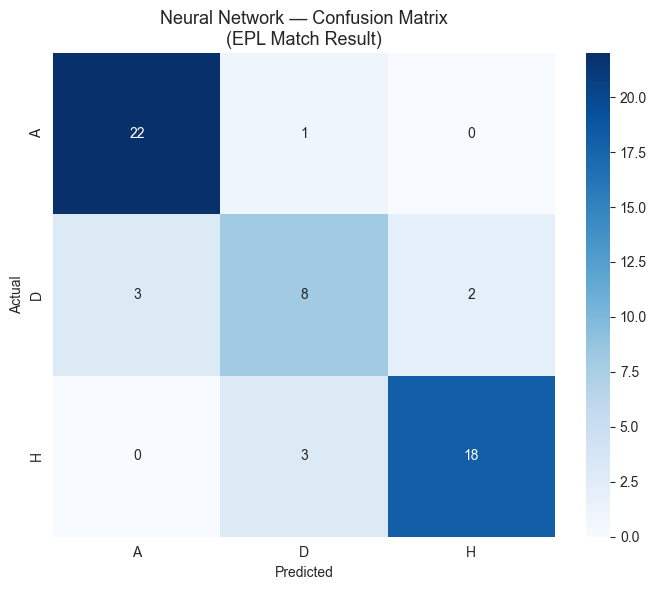

In [9]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Neural Network — Confusion Matrix\n(EPL Match Result)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../app/static/images/nn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

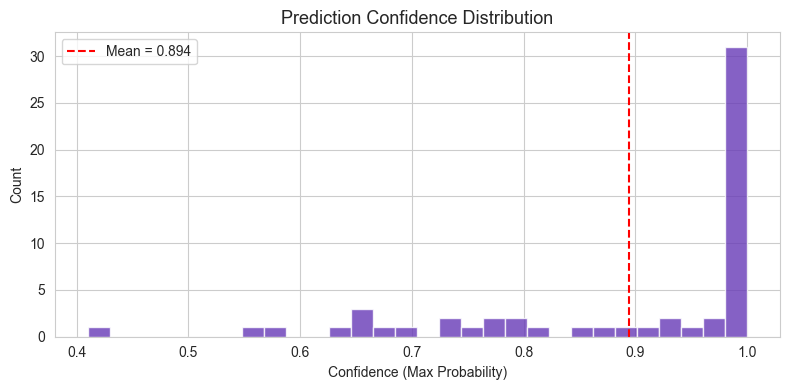

In [10]:
# Prediction Confidence Distribution
confidence = np.max(y_pred_proba, axis=1)
plt.figure(figsize=(8, 4))
plt.hist(confidence, bins=30, color='#673AB7', edgecolor='white', alpha=0.8)
plt.axvline(confidence.mean(), color='red', linestyle='--', label=f'Mean = {confidence.mean():.3f}')
plt.title('Prediction Confidence Distribution', fontsize=13)
plt.xlabel('Confidence (Max Probability)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../app/static/images/nn_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# บันทึก Scaler และ Metadata
joblib.dump(scaler_nn, '../models/scaler_nn.pkl')
joblib.dump({
    'feature_cols': feature_cols,
    'classes': le.classes_.tolist()
}, '../models/nn_metadata.pkl')

print('✓ Saved: nn_model.keras')
print('✓ Saved: scaler_nn.pkl')
print('✓ Saved: nn_metadata.pkl')
print('\n=== Phase 3 Complete! ===')

✓ Saved: nn_model.keras
✓ Saved: scaler_nn.pkl
✓ Saved: nn_metadata.pkl

=== Phase 3 Complete! ===
